<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);padding:28px 32px;border-radius:10px;margin-bottom:18px"><h1 style="color:white;margin:0 0 6px 0;font-size:1.9em">Financial Risk Management and Engineering — Session 2: Market Risk Basics — Returns, Volatility & Correlation</h1><p style="color:#BDC3C7;margin:0;font-size:1.0em">Aarhus Summer University · Summer 2026</p><p style="color:#85C1E9;margin:8px 0 0 0;font-size:0.9em">Stylised facts · EWMA · GARCH(1,1) · correlation & beta · forecast comparison</p></div>

This companion notebook turns the Session 1 price snapshot into the building blocks of market risk: returns, the stylised facts of their distribution, time-varying volatility models (EWMA and GARCH), and the correlation/beta structure that drives portfolio risk.

*Reference: Hull (2023) Ch. 8 (Volatility) & Ch. 9 (Correlations and Copulas); Jorion (2010) Financial Risk Manager Handbook, Ch. 5.*

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup &mdash; Required Packages &amp; Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy arch
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser &mdash; just upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy arch`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'arch', 'seaborn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.1.3
  pandas        2.2.3
  matplotlib    3.10.0
  scipy         1.17.1
  yfinance      0.2.55
  arch          8.0.0
  seaborn       0.13.2


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b> &mdash; order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute &mdash; this notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 0 — Toolkit & Data</span><br><span style="color:#BDC3C7;font-size:0.93em">Window: 2021-07-01 to 2026-07-01</span></div>

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.optimize import minimize
from arch import arch_model
try:
    import seaborn as sns
except Exception:
    sns = None
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12,
})
np.random.seed(42)

# ── Analysis period: last 5 years ──────────────────────────────────────────
START, END = '2021-07-01', '2026-07-01'
RF_ANNUAL = 0.04
RF_DAILY  = RF_ANNUAL / 252

TICKERS = ['SPY', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'NVDA']
CACHE = os.path.join('notebook_data', 'Session_02_data.csv')
os.makedirs('notebook_data', exist_ok=True)

def load_prices(tickers=TICKERS, cache=CACHE, ohlcv=False):
    """Load adjusted prices, caching a CSV snapshot for reproducibility."""
    if os.path.exists(cache):
        df = pd.read_csv(cache, index_col=0, parse_dates=True, header=[0, 1] if ohlcv else 0)
        print(f'Loaded snapshot: {cache}  ({df.shape[0]} rows)')
        return df
    last = None
    for attempt in range(3):
        try:
            raw = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
            if raw is not None and not raw.empty:
                df = raw if False else raw['Close']
                df = df.dropna(how='all')
                df.to_csv(cache)
                print(f'Downloaded {len(tickers)} tickers {START}–{END} '
                      f'({df.shape[0]} rows); snapshot saved to {cache}')
                return df
        except Exception as e:
            last = e
        time.sleep(3 * (attempt + 1))
    raise RuntimeError(f'yfinance download failed after retries: {last}')


In [3]:
prices = load_prices()[TICKERS].dropna()
simple = prices.pct_change().dropna()
logret = np.log(prices/prices.shift(1)).dropna()
print('Window:', logret.index[0].date(), 'to', logret.index[-1].date(), '|', len(logret), 'days')
display(prices.tail(3).round(2))

Loaded snapshot: notebook_data/Session_02_data.csv  (1255 rows)
Window: 2021-07-02 to 2026-07-01 | 1254 days


,SPY,AAPL,MSFT,JPM,XOM,JNJ,NVDA
Date,,,,,,,
2026-06-29,741.00,281.74,368.57,329.39,136.06,258.51,194.97
2026-06-30,746.77,289.36,373.02,327.33,136.72,253.97,200.09
2026-07-01,745.76,294.38,384.28,334.07,136.28,253.98,197.58


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 1 — Simple vs Log Returns & Stylised Facts</span><br><span style="color:#BDC3C7;font-size:0.93em">Fat tails, volatility clustering, no autocorrelation in levels</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Why log returns</b> · $r_t=\ln(P_t/P_{t-1})$ are <b>time-additive</b> ($r_{0\to n}=\sum r_t$) and closer to stationary, which is why risk models use them. For daily data simple and log returns are numerically very close.</div>

In [4]:
diff = (simple['SPY']-logret['SPY']).abs()
print(f'Max |simple - log| for SPY: {diff.max():.2e}  (tiny at daily frequency)')
spy = logret['SPY']
print(f'SPY  mean={spy.mean()*252:.3%}/yr  vol={spy.std()*np.sqrt(252):.2%}/yr  '
      f'skew={spy.skew():.2f}  exkurt={spy.kurtosis():.2f}')
jb,jbp = stats.jarque_bera(spy); print(f'Jarque-Bera p-value={jbp:.1e} -> reject normality')

Max |simple - log| for SPY: 5.16e-03  (tiny at daily frequency)
SPY  mean=12.404%/yr  vol=17.14%/yr  skew=0.14  exkurt=7.98
Jarque-Bera p-value=0.0e+00 -> reject normality


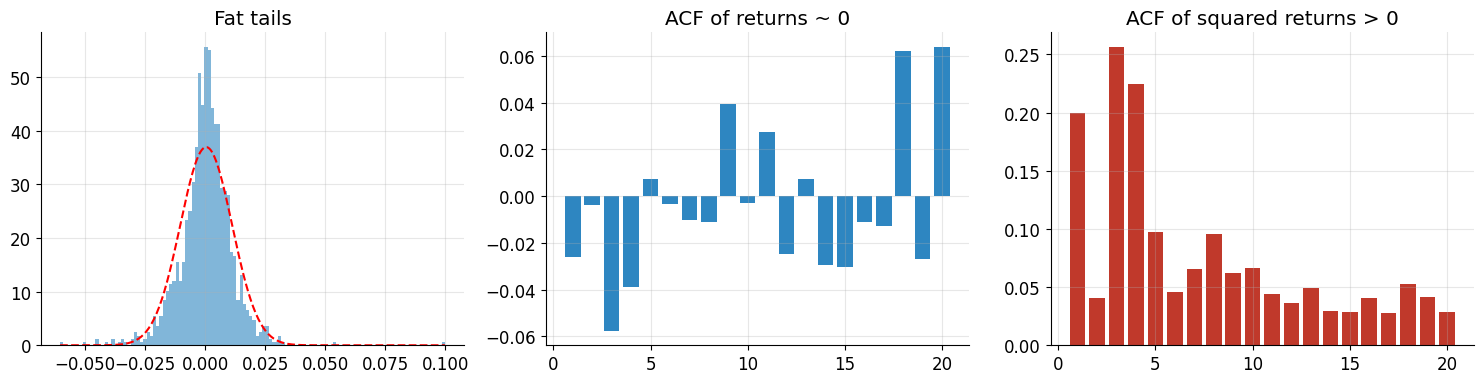

In [5]:
# Stylised facts: fat tails (hist), volatility clustering (ACF of r vs r^2)
from pandas.plotting import autocorrelation_plot
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].hist(spy, bins=120, density=True, alpha=.6, color='#2E86C1')
x=np.linspace(spy.min(),spy.max(),300)
axes[0].plot(x, stats.norm.pdf(x,spy.mean(),spy.std()),'r--'); axes[0].set_title('Fat tails')
def acf(s,k): return [s.autocorr(i) for i in range(1,k+1)]
axes[1].bar(range(1,21), acf(spy,20), color='#2E86C1'); axes[1].set_title('ACF of returns ~ 0')
axes[2].bar(range(1,21), acf(spy**2,20), color='#C0392B'); axes[2].set_title('ACF of squared returns > 0')
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> Three stylised facts, all visible above: returns are <b>fat-tailed</b>, show <b>no</b> linear autocorrelation, but their <b>squares are strongly autocorrelated</b> — i.e. <b>volatility clusters</b>. EWMA and GARCH exist to capture that clustering.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 2 — Time-Varying Volatility: EWMA & GARCH(1,1)</span><br><span style="color:#BDC3C7;font-size:0.93em">From a smoothing scheme to a mean-reverting model</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Models</b> · EWMA: $\sigma^2_t=\lambda\sigma^2_{t-1}+(1-\lambda)r^2_{t-1}$ (RiskMetrics $\lambda=0.94$). GARCH(1,1): $\sigma^2_t=\omega+\alpha r^2_{t-1}+\beta\sigma^2_{t-1}$, with persistence $\alpha+\beta$ and long-run variance $\omega/(1-\alpha-\beta)$.</div>

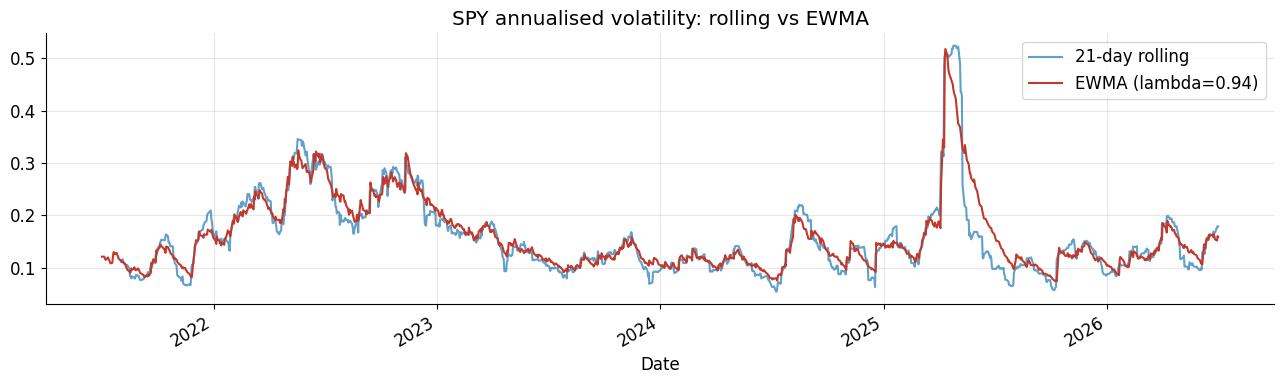

In [6]:
# EWMA recursion (lambda=0.94)
lam=0.94; r=spy.values; ew=np.zeros(len(r)); ew[0]=r[0]**2
for t in range(1,len(r)): ew[t]=lam*ew[t-1]+(1-lam)*r[t-1]**2
ewma_vol=pd.Series(np.sqrt(ew*252), index=spy.index)
hist_vol=spy.rolling(21).std()*np.sqrt(252)
fig,ax=plt.subplots(figsize=(13,4))
hist_vol.plot(ax=ax,label='21-day rolling',alpha=.7)
ewma_vol.plot(ax=ax,label='EWMA (lambda=0.94)',color='#C0392B')
ax.set_title('SPY annualised volatility: rolling vs EWMA'); ax.legend(); plt.tight_layout(); plt.show()

omega=0.0275  alpha=0.105  beta=0.873
persistence alpha+beta=0.9782  long-run vol=17.85%/yr  half-life=32 days


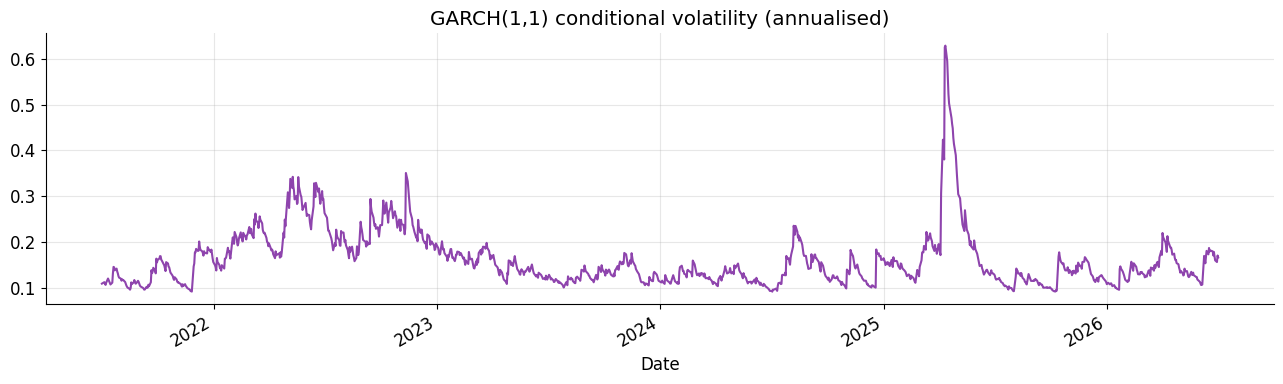

In [7]:
# GARCH(1,1) with Student-t errors via the arch library (returns in % units)
am = arch_model(spy*100, vol='Garch', p=1, q=1, dist='t', mean='Zero')
res = am.fit(disp='off')
w,a,b = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
persist=a+b; lr_vol=np.sqrt(w/(1-persist))*np.sqrt(252)/100
half=np.log(0.5)/np.log(persist)
print(f'omega={w:.4f}  alpha={a:.3f}  beta={b:.3f}')
print(f'persistence alpha+beta={persist:.4f}  long-run vol={lr_vol:.2%}/yr  half-life={half:.0f} days')
cond=res.conditional_volatility*np.sqrt(252)/100
cond.index=spy.index
fig,ax=plt.subplots(figsize=(13,4)); cond.plot(ax=ax,color='#8E44AD')
ax.set_title('GARCH(1,1) conditional volatility (annualised)'); plt.tight_layout(); plt.show()

<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> High persistence ($\alpha+\beta$ close to 1) means volatility shocks decay slowly, so a shock today still inflates next week's VaR. EWMA is the special case $\omega=0,\;\alpha+\beta=1$ — no mean reversion at all.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 3 — Correlation & Beta</span><br><span style="color:#BDC3C7;font-size:0.93em">Diversification and systematic risk</span></div>

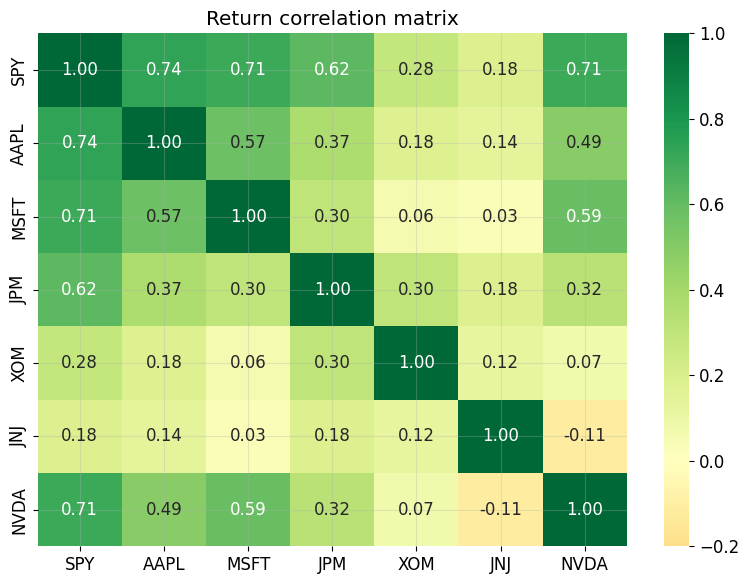

In [8]:
corr = logret.corr()
fig,ax=plt.subplots(figsize=(8,6))
if sns is not None:
    sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdYlGn',center=0,vmin=-.2,vmax=1,ax=ax)
else:
    im=ax.imshow(corr,cmap='RdYlGn',vmin=-.2,vmax=1); fig.colorbar(im)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns,rotation=45)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
ax.set_title('Return correlation matrix'); plt.tight_layout(); plt.show()

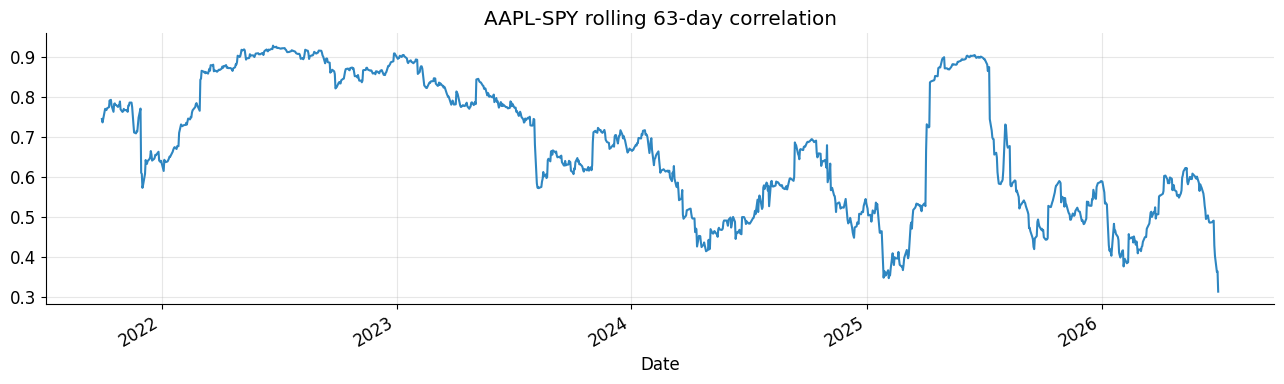

In [9]:
# Rolling 63-day correlation of AAPL vs SPY — note the regime shifts
roll = logret['AAPL'].rolling(63).corr(logret['SPY'])
roll.plot(figsize=(13,4),color='#2E86C1',title='AAPL-SPY rolling 63-day correlation')
plt.tight_layout(); plt.show()

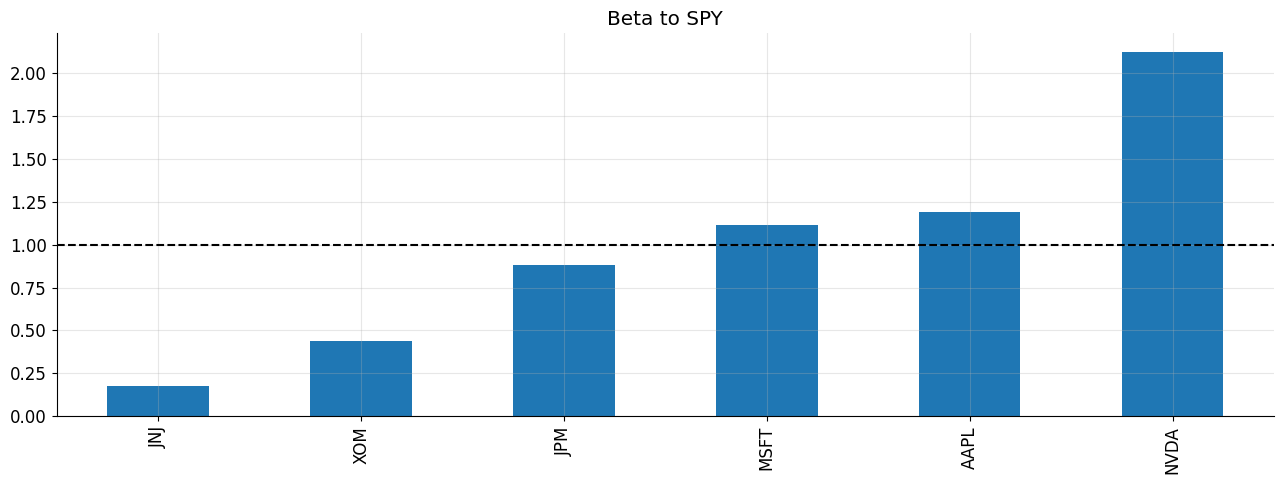

JNJ     0.18
XOM     0.44
JPM     0.88
MSFT    1.11
AAPL    1.19
NVDA    2.12


In [10]:
# CAPM beta of each stock to SPY (OLS)
mkt = logret['SPY']
betas={}
for t in TICKERS:
    if t=='SPY': continue
    cov=np.cov(logret[t], mkt); betas[t]=cov[0,1]/cov[1,1]
beta_s=pd.Series(betas).sort_values()
beta_s.plot(kind='bar',color='#1F77B4',title='Beta to SPY'); plt.axhline(1,color='k',ls='--')
plt.tight_layout(); plt.show(); print(beta_s.round(2).to_string())

In [11]:
# Forecast comparison via QLIKE loss (lower is better): rolling 21-day vs EWMA vs GARCH
realized = spy**2
garch_var = (res.conditional_volatility/100)**2; garch_var=pd.Series(garch_var.values,index=spy.index)
roll_var = spy.rolling(21).var()
ewma_var = pd.Series(ew, index=spy.index)
def qlike(v): 
    m=(v>0)&realized.notna(); return float(np.mean(np.log(v[m])+realized[m]/v[m]))
print('QLIKE (lower=better):')
print(f'  rolling-21 = {qlike(roll_var):.4f}')
print(f'  EWMA       = {qlike(ewma_var):.4f}')
print(f'  GARCH(1,1) = {qlike(garch_var):.4f}')

QLIKE (lower=better):
  rolling-21 = -8.4002
  EWMA       = -8.2538
  GARCH(1,1) = -8.2913


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> GARCH usually wins the QLIKE comparison because it mean-reverts; EWMA is close and far simpler. Pick a volatility model now — you will reuse it for VaR and Expected Shortfall in Sessions 3–4 and Assignment 1.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Your Turn — Market Risk on Your Own Stocks</span><br><span style="color:#BDC3C7;font-size:0.93em">Parts A–E · your three stocks + bloc index</span></div>

## Part A — Data & returns
Download your stocks + index (2021-07-01 to 2026-07-01); compute log returns.

## Part B — Stylised facts
For one stock: histogram vs normal, skew, excess kurtosis, Jarque-Bera, and ACF of $r$ vs $r^2$.

## Part C — Volatility models
Compute EWMA ($\lambda=0.94$) and fit GARCH(1,1); report persistence, long-run vol, half-life.

## Part D — Correlation & beta
Correlation matrix + each stock's beta to your index.

## Part E — Model choice
Use QLIKE to choose the volatility model you will carry into your VaR work, and justify it.

In [12]:
# YOUR CODE HERE


In [13]:
# YOUR CODE HERE


In [14]:
# YOUR CODE HERE


In [15]:
# YOUR CODE HERE


<sub>Yuriy Zabolotnyuk · Sprott School of Business · Carleton University</sub>